# Tier 5 · Notebook 24 — Generative Adversarial Networks (GANs)

> **Goal:** build a **GAN** — two networks locked in a game, one generating fakes and one detecting them — which produces *much sharper* samples than a VAE, at the cost of notorious training instability. We derive the adversarial objective, train a GAN on a 2-D toy to *see* the dynamics and the infamous **mode collapse**, then generate MNIST digits.

**The adversarial idea (Goodfellow et al. 2014).** Instead of a likelihood-based loss (like the VAE's ELBO), a GAN sets up a **two-player game**:
- The **Generator** $G$ takes random noise $z$ and produces a fake sample $G(z)$. Its goal: fool the discriminator.
- The **Discriminator** $D$ takes a sample and outputs the probability it's *real*. Its goal: correctly tell real data from $G$'s fakes.

They train against each other: $D$ gets better at spotting fakes, which pushes $G$ to make more realistic fakes, which pushes $D$ to get sharper, … At equilibrium, $G$'s samples are indistinguishable from real data and $D$ is reduced to guessing (output 0.5). Because there's no blurry averaging (no reconstruction term), GAN samples are **crisp** — but the game is delicate and can break in fascinating ways.


## 0. The minimax objective

The original GAN value function:
$$\min_G \max_D \; \mathbb{E}_{x\sim\text{data}}[\log D(x)] + \mathbb{E}_{z}[\log(1 - D(G(z)))].$$
$D$ maximizes it (assign high $D(x)$ to real, low $D(G(z))$ to fake); $G$ minimizes it (make $D(G(z))$ high). In practice $G$ is trained with the **non-saturating** version — maximize $\log D(G(z))$ instead of minimizing $\log(1-D(G(z)))$ — because the original gives $G$ vanishing gradients early when its fakes are easily caught. Both reduce to **binary cross-entropy** with flipped labels, which is all we need to implement.


device: cuda


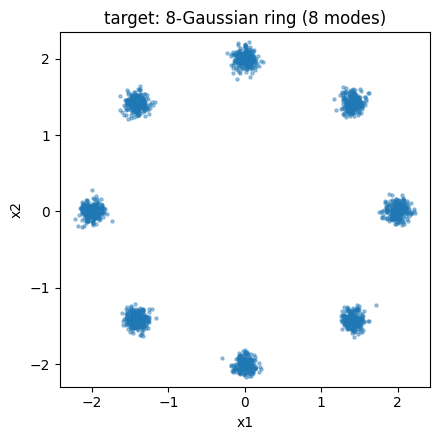

In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# a 2-D target distribution: 8 Gaussians arranged in a ring (the classic mode-collapse testbed)
def sample_real(n):
    centers = np.array([[np.cos(t), np.sin(t)] for t in np.linspace(0, 2*np.pi, 8, endpoint=False)]) * 2
    idx = np.random.randint(0, 8, n)
    return torch.tensor(centers[idx] + np.random.randn(n,2)*0.08, dtype=torch.float32)

real = sample_real(2000)
plt.figure(figsize=(4.5,4.5)); plt.scatter(real[:,0], real[:,1], s=5, alpha=0.4)
plt.title("target: 8-Gaussian ring (8 modes)"); plt.xlabel("x1"); plt.ylabel("x2"); plt.axis("equal"); plt.tight_layout(); plt.show()


## 1. Train a GAN on the ring — watch the game

Small generator (noise → 2-D) and discriminator (2-D → real/fake probability). We alternate: update $D$ on a batch of real + fake, then update $G$ to fool the current $D$. We snapshot $G$'s samples over training to watch it try to cover the 8 modes.


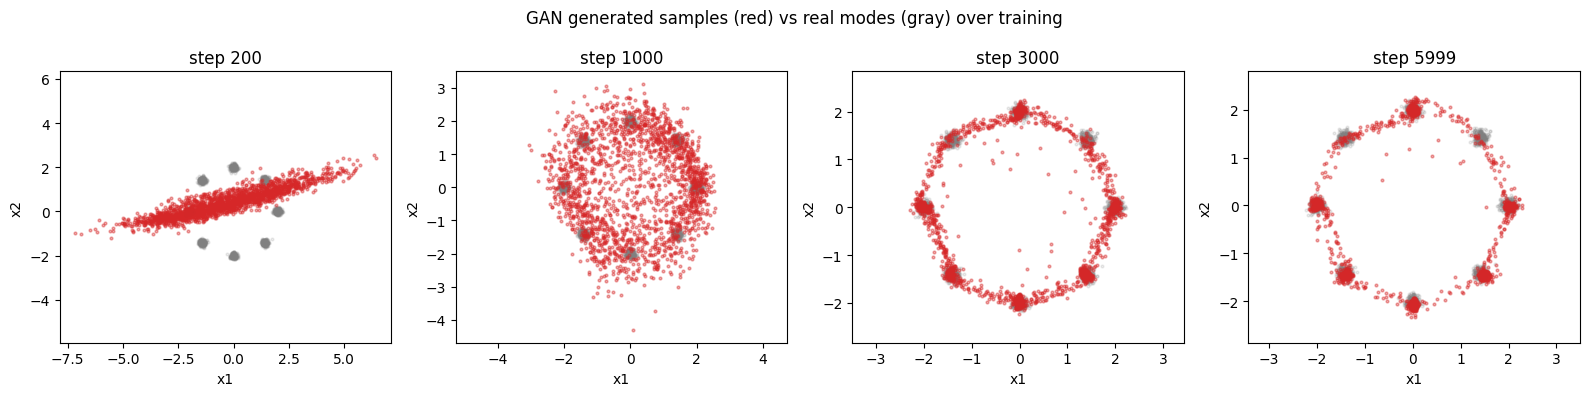

In [2]:
Z = 8
G = nn.Sequential(nn.Linear(Z,128), nn.ReLU(), nn.Linear(128,128), nn.ReLU(), nn.Linear(128,2)).to(device)
D = nn.Sequential(nn.Linear(2,128), nn.ReLU(), nn.Linear(128,128), nn.ReLU(), nn.Linear(128,1)).to(device)
optG = torch.optim.Adam(G.parameters(), 2e-4, betas=(0.5,0.999))
optD = torch.optim.Adam(D.parameters(), 2e-4, betas=(0.5,0.999))
bce = nn.BCEWithLogitsLoss()

snapshots = {}; g_losses=[]; d_losses=[]
for step in range(6000):
    x = sample_real(256).to(device); z = torch.randn(256, Z, device=device)
    # --- train D: real -> 1, fake -> 0 ---
    fake = G(z).detach()
    lossD = bce(D(x), torch.ones(256,1,device=device)) + bce(D(fake), torch.zeros(256,1,device=device))
    optD.zero_grad(); lossD.backward(); optD.step()
    # --- train G: want D(G(z)) -> 1 (non-saturating) ---
    z = torch.randn(256, Z, device=device)
    lossG = bce(D(G(z)), torch.ones(256,1,device=device))
    optG.zero_grad(); lossG.backward(); optG.step()
    g_losses.append(lossG.item()); d_losses.append(lossD.item())
    if step in (200, 1000, 3000, 5999):
        with torch.no_grad(): snapshots[step] = G(torch.randn(2000, Z, device=device)).cpu().numpy()

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a,(s,pts) in zip(ax, snapshots.items()):
    a.scatter(real[:,0], real[:,1], s=4, alpha=0.15, color="gray")
    a.scatter(pts[:,0], pts[:,1], s=4, alpha=0.4, color="tab:red")
    a.set_title(f"step {s}"); a.set_xlabel("x1"); a.set_ylabel("x2"); a.axis("equal")
fig.suptitle("GAN generated samples (red) vs real modes (gray) over training"); plt.tight_layout(); plt.show()


**What to notice.** Watch $G$'s red samples evolve: from a random blob (step 200) toward the real modes. A well-behaved run spreads out to cover the ring; but GANs are famous for **mode collapse** — $G$ discovers a few modes that reliably fool $D$ and *piles all its output there*, ignoring the rest (you'll often see the red points cover only some of the 8 clusters, or oscillate between them as $D$ chases $G$). This happens because $G$'s objective only asks it to fool $D$, *not* to be diverse — producing one perfect mode gets full marks. Mode collapse is the single most notorious GAN failure, and much of GAN research (minibatch discrimination, WGAN, unrolled GANs) is about fixing it.


## 2. The adversarial dynamics — losses don't converge like normal training

Look at the two networks' losses over training. Unlike a normal loss that steadily decreases, GAN losses **oscillate** and stay in tension — because it's a *game*, not an optimization toward a fixed target. Neither player can "win" permanently.


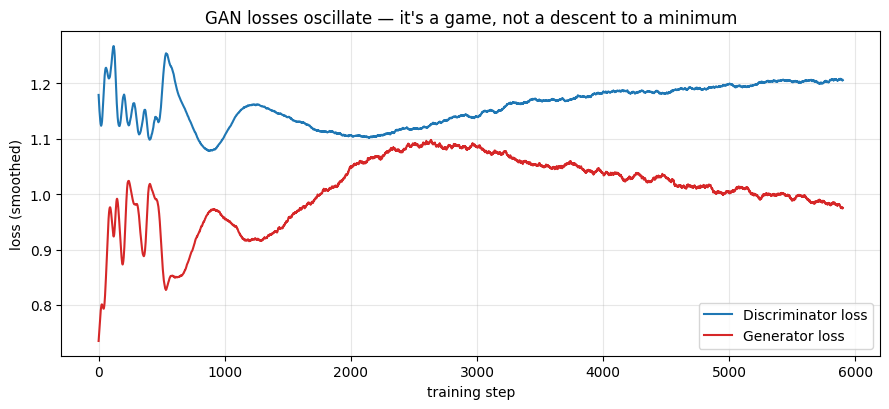

Neither loss goes to 0: at equilibrium D outputs ~0.5 (can't tell real from fake) and both losses hover.


In [3]:
fig, ax = plt.subplots(figsize=(9,4.2))
sm = lambda a,w=100: np.convolve(a, np.ones(w)/w, mode="valid")
ax.plot(sm(d_losses), label="Discriminator loss", color="tab:blue")
ax.plot(sm(g_losses), label="Generator loss", color="tab:red")
ax.set_title("GAN losses oscillate — it's a game, not a descent to a minimum")
ax.set_xlabel("training step"); ax.set_ylabel("loss (smoothed)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Neither loss goes to 0: at equilibrium D outputs ~0.5 (can't tell real from fake) and both losses hover.")
d_final = np.mean(d_losses[-200:])
assert 0.2 < d_final < 1.5, (
    f"discriminator loss settled at {d_final:.3f} - one player won outright, "
    f"so this is not the equilibrium the text describes")


**What to notice.** The generator and discriminator losses stay **locked in tension** rather than converging to zero — when $G$ improves, $D$'s job gets harder (its loss rises) and vice-versa. There's no single loss curve to watch go down; you monitor *sample quality* instead. This is why GANs are hard to train: no clear "is it working?" signal, sensitivity to hyperparameters and architecture, and failure modes (collapse, oscillation, $D$ winning and starving $G$'s gradient). Diffusion models (NB25) get GAN-level sharpness with the *stability* of a simple regression loss — a big reason they overtook GANs.


## 3. GAN on MNIST — sharper than the VAE

Now images. A small GAN on MNIST produces digits noticeably **crisper** than the VAE's (NB23) — no blurry reconstruction term, just "look real to $D$." (Still a small model, so not perfect, but the sharpness difference is visible.)


epoch 0  D 0.719  G 2.201


epoch 1  D 0.571  G 2.797


epoch 2  D 0.707  G 2.801


epoch 3  D 0.739  G 1.576


epoch 4  D 0.452  G 2.451


epoch 5  D 0.534  G 2.147


epoch 6  D 0.506  G 2.991


epoch 7  D 0.646  G 1.577


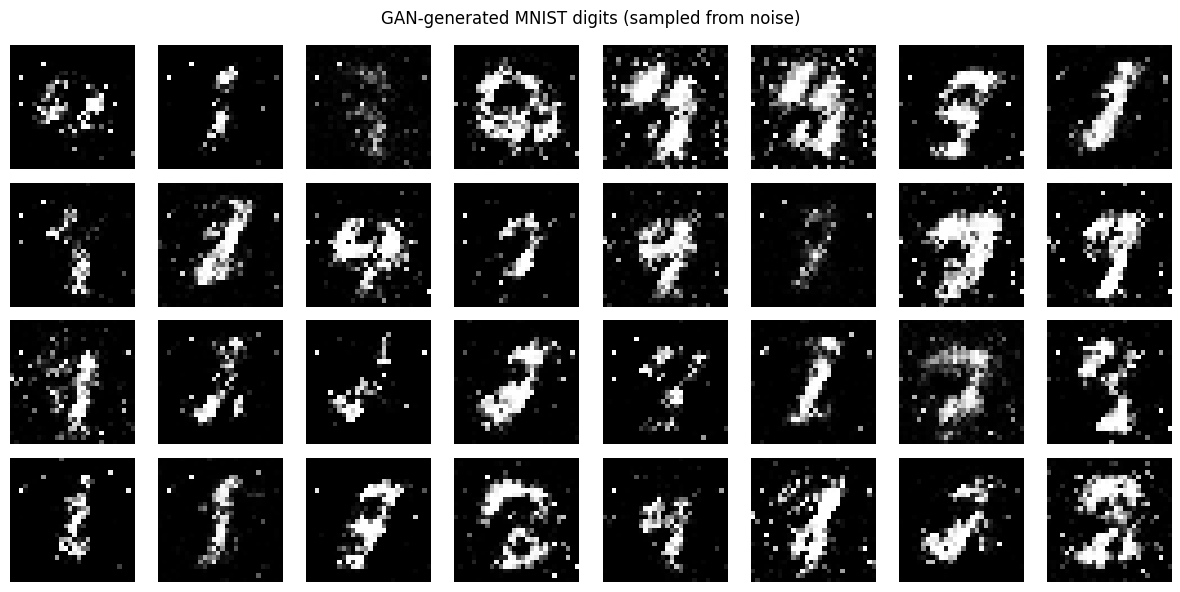

In [4]:
from torchvision import datasets, transforms
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])  # -> [-1,1]
ld = torch.utils.data.DataLoader(datasets.MNIST("../data", train=True, download=True, transform=tf),
                                 batch_size=128, shuffle=True, drop_last=True)
ZI = 64
Gi = nn.Sequential(nn.Linear(ZI,256), nn.LeakyReLU(0.2), nn.Linear(256,512), nn.LeakyReLU(0.2),
                   nn.Linear(512,784), nn.Tanh()).to(device)
Di = nn.Sequential(nn.Linear(784,512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
                   nn.Linear(512,256), nn.LeakyReLU(0.2), nn.Linear(256,1)).to(device)
oG = torch.optim.Adam(Gi.parameters(), 2e-4, betas=(0.5,0.999))
oD = torch.optim.Adam(Di.parameters(), 2e-4, betas=(0.5,0.999))
bce = nn.BCEWithLogitsLoss()
for epoch in range(8):
    for x,_ in ld:
        x = x.view(-1,784).to(device); b = x.size(0)
        z = torch.randn(b, ZI, device=device); fake = Gi(z).detach()
        lD = bce(Di(x), torch.ones(b,1,device=device)) + bce(Di(fake), torch.zeros(b,1,device=device))
        oD.zero_grad(); lD.backward(); oD.step()
        z = torch.randn(b, ZI, device=device)
        lG = bce(Di(Gi(z)), torch.ones(b,1,device=device))
        oG.zero_grad(); lG.backward(); oG.step()
    print(f"epoch {epoch}  D {lD.item():.3f}  G {lG.item():.3f}")

with torch.no_grad(): samples = Gi(torch.randn(32, ZI, device=device)).cpu().view(-1,28,28)
fig, ax = plt.subplots(4, 8, figsize=(12, 6))
for i,a in enumerate(ax.ravel()): a.imshow(samples[i]*0.5+0.5, cmap="gray"); a.axis("off")
fig.suptitle("GAN-generated MNIST digits (sampled from noise)"); plt.tight_layout(); plt.show()


**What to notice.** The GAN's digits are **sharper** than the VAE's — cleaner strokes, less of that smeared-average look — because $G$ is only rewarded for *looking real*, with no pixel-averaging reconstruction term to blur things. You may also spot GAN artifacts (a few malformed digits, or several samples that look alike — a hint of mode collapse). That's the GAN bargain: **sharper samples, shakier training.** For a decade GANs (DCGAN, StyleGAN, BigGAN) were the state of the art in image generation; diffusion models eventually matched their quality with far more stable training, which we build next.

## 4. What you built / learned
- The **adversarial minimax game**: generator vs discriminator, both trained with BCE.
- The **non-saturating** generator loss (avoids vanishing gradients early).
- **Mode collapse** and oscillating, non-converging losses — the GAN's characteristic failures — seen on a 2-D ring.
- A **MNIST GAN** producing sharper samples than the VAE.

## 5. Exercises
1. **Induce/fix collapse.** Make the generator tiny or train D too hard; watch collapse. Then add minibatch std (feature) to fix it.
2. **WGAN.** Replace BCE with the Wasserstein loss + gradient penalty; is training more stable on the ring?
3. **Label the modes.** Count how many of the 8 modes your GAN covers over training; quantify collapse.
4. **DCGAN.** Swap MLPs for conv/transpose-conv; compare MNIST sharpness.
5. **Conditional GAN.** Condition G and D on the digit label; generate a chosen digit.
6. **Evaluation.** GANs have no likelihood — how do you measure sample quality? (Read about FID / Inception Score.)

## 6. Interview / residency framing
- *"How does a GAN work?"* → generator makes fakes from noise, discriminator classifies real vs fake; adversarial minimax; at equilibrium fakes are indistinguishable and D≈0.5.
- *"Non-saturating loss?"* → train G to maximize log D(G(z)) instead of minimizing log(1−D(G(z))) to avoid vanishing gradients when fakes are easily caught.
- *"What is mode collapse?"* → G maps many/all noise to a few outputs that fool D, ignoring data diversity; G is rewarded for realism, not coverage.
- *"Why are GANs hard to train?"* → it's a game with no convergent loss to monitor; sensitive to hyperparameters; failure modes (collapse, oscillation, D starving G).
- *"GAN vs VAE vs diffusion?"* → GAN: sharp, unstable, no likelihood; VAE: stable, blurry, likelihood bound; diffusion: sharp + stable, iterative, slower sampling.

## 📚 References & papers

This notebook reproduces / builds on:

- **Generative Adversarial Networks** — Goodfellow et al. (2014), arXiv:1406.2661. The original GAN.
- **Unsupervised Representation Learning with Deep Convolutional GANs (DCGAN)** — Radford, Metz & Chintala (2015), arXiv:1511.06434.
- **Wasserstein GAN** — Arjovsky, Chintala & Bottou (2017), arXiv:1701.07875. Stabilizing the training.
- **Improved Techniques for Training GANs** — Salimans et al. (2016), arXiv:1606.03498. Mode-collapse fixes, Inception Score.

---
**Next:** *Tier 5 · Notebook 25 — Diffusion (DDPM) from scratch*: the generative model behind DALL·E/Stable Diffusion — gradually add noise, then learn to reverse it — sharp samples with stable training.
